# RSNA Knee Abnormality Detection - EDA(Exploratory Data Analysis) 【English + 日本語】

### Credits:

- https://www.kaggle.com/code/liamob96/knee-abnormality-eda
- https://www.kaggle.com/code/stevenleehans/rsna-knee-101-read-this-before-you-start

## Objective(目的)

The goal of this competition is to predict 12 knee abnormalities from MRI studies. The training data also contain multilingual radiology reports, which may provide supervision for studies without structured target labels.

このコンペティションの目的は、MRI研究から12の膝の異常を予測することです。トレーニングデータには、多言語の放射線レポートも含まれており、構造化されたターゲットラベルがない研究に対して監督を提供する可能性があります。


# What are the 12 knee abnormalities? (12の膝の異常とは何ですか？)

12 Knee abnormalities are **diffrent things, of different sizes, in diffrent places in the knee**.
It is hard to describe to non-medical people, but they are all things that can be seen on MRI images of the knee.

The anatomy table below is _background_ — it comes from radiology, not from measuring this dataset. Everything after it is measured from the competition data. The notebook keeps those two kinds of claim visibly separate, and so should you.

## The knee in four sentences

The knee is where the **femur** (thigh bone) meets the **tibia** (shin bone), with the
**patella** (kneecap) riding in a groove at the front.

Between femur and tibia sit two crescent-shaped shock absorbers, the **menisci** — one on
the inner side (**medial**) and one on the outer (**lateral**).

Four ligaments hold it together; two of them are targets here — the **ACL** (anterior
cruciate ligament, deep in the middle) and the **MCL** (medial collateral, on the inner
edge).

Everything is wrapped in a capsule lined with **synovium**, which makes lubricating fluid —
and which, when it misbehaves, produces most of the remaining targets.

## The twelve, one line each

| #   | Target               | What it is                                       | Where it lives                       | Rough size                |
| --- | -------------------- | ------------------------------------------------ | ------------------------------------ | ------------------------- |
| 1   | **ACL**              | tear/sprain of the central stabilising ligament  | intercondylar notch, dead centre     | 7–11 mm thick             |
| 2   | **MCL**              | tear/sprain of the inner-side ligament           | medial edge of the joint             | 2–4 mm thick              |
| 3   | **Medial Meniscus**  | tear or degeneration of the inner shock absorber | inner joint line                     | 9–12 mm wide, tear 1–3 mm |
| 4   | **Lateral Meniscus** | same, outer side                                 | outer joint line                     | 9–12 mm wide, tear 1–3 mm |
| 5   | **Medial OA**        | cartilage loss / arthritis, inner compartment    | inner femur–tibia contact            | cartilage 2–4 mm          |
| 6   | **Lateral OA**       | same, outer compartment                          | outer femur–tibia contact            | cartilage 2–4 mm          |
| 7   | **PF OA**            | arthritis behind the kneecap                     | patella–femur groove, front          | cartilage 2–4 mm          |
| 8   | **Effusion**         | excess fluid in the joint                        | pools **above** the kneecap          | 10–50 mm collection       |
| 9   | **Synovitis**        | inflamed, thickened joint lining                 | throughout the capsule               | diffuse, ill-defined      |
| 10  | **Baker's**          | fluid-filled cyst                                | **behind** the knee, popliteal fossa | 20–50 mm                  |
| 11  | **Contusion**        | bone bruise — marrow swelling, no break          | inside the bone ends                 | 10–30 mm patch            |
| 12  | **Fracture**         | actual break in the bone                         | anywhere in femur/tibia/patella      | line, <1 mm wide          |

Two columns in that table are doing quiet work. **Size** tells you what resolution you need. **Where** tells you what happens if you crop too tightly — note that Effusion lives _above_ the joint and Baker's lives _behind_ it, so both sit near the edge of the field of view rather than in the middle.

---

12の膝の異常（Knee abnormalities）は、**膝の中の異なる場所に起こる、さまざまな種類・大きさの異常**です。

医学の知識がない人に説明するのは少し難しいですが、これらはすべて**膝のMRI画像から確認できる異常**です。

以下の解剖学的な説明は、**このコンペティションのデータを測定した結果ではなく、放射線医学などの一般的な医学知識に基づく背景情報**です。

一方、それ以降の内容は**コンペティションのデータから測定された情報**です。

## 膝を4つの文章で理解する

膝は、**大腿骨（femur）**と**脛骨（tibia）**が接する場所です。
その前側には、**膝蓋骨（patella）**、いわゆる「膝のお皿」があります。

大腿骨と脛骨の間には、2つの三日月形をしたクッションのような構造があります。これが**半月板（menisci）**です。

内側にあるものを**内側半月板（medial meniscus）**、外側にあるものを**外側半月板（lateral meniscus）**と呼びます。

膝は4本の主要な靭帯によって支えられており、このコンペティションでは、そのうち**ACL（前十字靭帯）**と**MCL（内側側副靭帯）**が対象になります。

膝全体は**関節包（joint capsule）**に包まれており、その内側には**滑膜（synovium）**があります。滑膜は関節を滑らかに動かすための液体を作ります。この滑膜に異常が起こると、今回の対象となるいくつかの異常につながります。

## 12の異常を1行ずつ理解する

| #   | 対象                 | 何が起こっている？                   | どこにある？               | おおよその大きさ        |
| --- | -------------------- | ------------------------------------ | -------------------------- | ----------------------- |
| 1   | **ACL**              | 膝の中央を支える靭帯の損傷・断裂     | 膝の中央にある顆間窩       | 厚さ 7–11 mm            |
| 2   | **MCL**              | 膝の内側にある靭帯の損傷・断裂       | 関節の内側                 | 厚さ 2–4 mm             |
| 3   | **Medial Meniscus**  | 内側の半月板の断裂・変性             | 膝の内側の関節裂隙         | 幅 9–12 mm、断裂 1–3 mm |
| 4   | **Lateral Meniscus** | 外側の半月板の断裂・変性             | 膝の外側の関節裂隙         | 幅 9–12 mm、断裂 1–3 mm |
| 5   | **Medial OA**        | 軟骨の減少・関節炎                   | 膝の内側の大腿骨–脛骨間    | 軟骨 2–4 mm             |
| 6   | **Lateral OA**       | 軟骨の減少・関節炎                   | 膝の外側の大腿骨–脛骨間    | 軟骨 2–4 mm             |
| 7   | **PF OA**            | 膝蓋骨の裏側に起こる関節炎           | 膝蓋骨と大腿骨の溝         | 軟骨 2–4 mm             |
| 8   | **Effusion**         | 関節内に液体が過剰にたまる           | 膝蓋骨の**上側**           | 液体のたまり 10–50 mm   |
| 9   | **Synovitis**        | 滑膜が炎症を起こし、厚くなる         | 関節包の内部全体           | 広範囲・明確な境界なし  |
| 10  | **Baker's**          | 液体がたまった嚢胞（のう胞）         | 膝の**後ろ側**             | 20–50 mm                |
| 11  | **Contusion**        | 骨の打撲による骨髄の腫れ。骨折はない | 大腿骨・脛骨などの骨端内部 | 10–30 mm程度            |
| 12  | **Fracture**         | 骨そのものが折れている状態           | 大腿骨・脛骨・膝蓋骨など   | 線状、幅 1 mm 未満      |

## 「大きさ」と「場所」が重要な理由

この表の中で、特に重要なのが**「大きさ」と「場所」**です。

**大きさ**は、MRI画像をどの程度の解像度で見る必要があるかに関係します。

例えば、靭帯や骨折のように比較的小さな異常を見つけるには、細かい部分まで確認できる画像が必要になります。

一方、**場所**は画像を切り取る（crop）ときに重要です。

例えば、

- **Effusion** → 膝関節の**上側**に液体がたまる
- **Baker's** → 膝関節の**後ろ側**にできる

そのため、膝の中央部分だけを狭く切り取ってしまうと、これらの異常を見落とす可能性があります。

つまり、**「何が異常なのか」だけでなく、「どこにあるのか」「どのくらい小さいのか」もMRI画像を扱う上で重要**です。

## Image of the 12 knee abnormalities (12の膝の異常の画像)

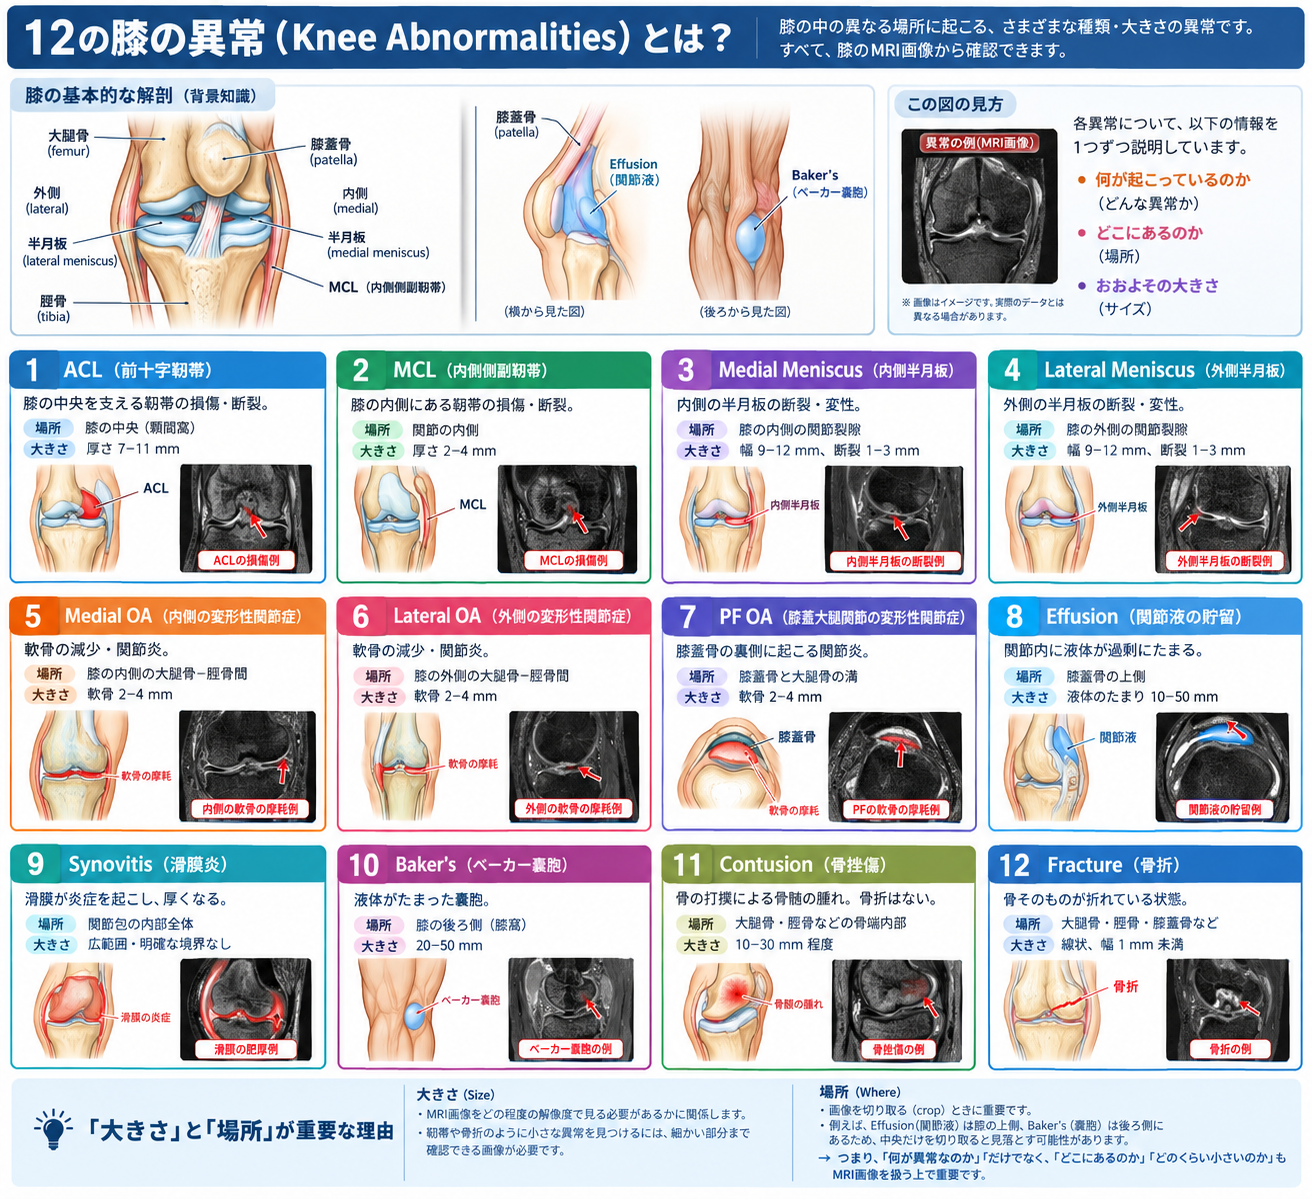


# 1. Data Overview(データ概要)

This notebook examines the dataset at the study, series, report and image levels before modelling. Particular attention is given to the unusually small gold-labelled subset, possible leakage routes, MRI acquisition variability and a reproducible validation design.

> **Important:** missing target values mean _unlabelled_, not _negative_. Series and slices from the same study must remain together, and patient-level grouping must be investigated separately.

## 1.1 Dataset at a glance

| Item                        | Visible competition data |
| --------------------------- | -----------------------: |
| Training studies            |                    4,407 |
| Fully gold-labelled studies |                       58 |
| Report-only studies         |                    4,349 |
| Prediction targets          |                       12 |
| Training MRI series         |                   24,371 |
| Visible test studies        |                        3 |
| Predicted report languages  |                        9 |

このノートブックでは、モデリングの前に、研究、シリーズ、レポート、および画像レベルでデータセットを調べます。特に、異常に小さいゴールドラベル付きサブセット、可能なリークルート、MRI取得の変動性、および再現可能な検証設計に注意が払われます。

> **重要:** ターゲット値が欠落している場合は、*ラベルなし*を意味し、*負*を意味しません。同じ研究からのシリーズとスライスは一緒に保持する必要があり、患者レベルのグループ化は別途調査する必要があります。


# 2. Read the data(データの読み込み)


## 2.1. Import libraries(ライブラリのインポート)


In [1]:
# ===================================
# 2.1. Imports and settings(インポートと設定)
# ===================================

from pathlib import Path
from collections import Counter
import os
import warnings
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 10

# Change the path to your dataset directory(データセットディレクトリへのパスを変更してください)
# Kaggle
# DATA_ROOT = Path("/kaggle/input/competitions/rsna-knee-abnormality-detection/")
DATA_ROOT = Path("E:/rsna-knee-abnormality-detection")

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

sns.set_theme(style="whitegrid", palette="muted", context="notebook")

print(f"NumPy:      {metadata.version('numpy')}")
print(f"Pandas:     {metadata.version('pandas')}")
print(f"Matplotlib: {metadata.version('matplotlib')}")
print(f"Seaborn:    {metadata.version('seaborn')}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Input root:  {DATA_ROOT}")

NumPy:      2.3.5
Pandas:     2.3.3
Matplotlib: 3.10.0
Seaborn:    0.13.2
Random seed: 10
Input root:  E:\rsna-knee-abnormality-detection


## 2.2. Load the data(データの読み込み)


In [2]:
# ===================================
# 2.2.1. Load data(データの読み込み)
# ===================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Data root directory '{DATA_ROOT}' does not exist.")


def describe_entry(path: Path) -> dict:
    """Describe a file or directory entry."""
    if path.is_file():
        return {
            "name": path.name,
            "type": "file",
            "size_mb": path.stat().st_size / 1024**2,
            "children": np.nan,
        }

    children = list(path.iterdir())

    return {
        "name": path.name,
        "type": "directory",
        "size_mb": np.nan,
        "children": len(children),
    }


input_summary = pd.DataFrame([describe_entry(path) for path in DATA_ROOT.iterdir()])

display(input_summary)

,name,type,size_mb,children
0,sample_submission.csv,file,0.0004,NaN
1,test.csv,file,0.0002,NaN
2,test_series.csv,file,0.0021,NaN
3,test_series,directory,NaN,3.0000
4,train.csv,file,5.4264,NaN
5,train_series.csv,file,3.2986,NaN
6,train_series,directory,NaN,4407.0000


In [3]:
# ============================================================
# 2.2.2 Load the tabular competition files
# ============================================================

TRAIN_PATH = DATA_ROOT / "train.csv"
TEST_PATH = DATA_ROOT / "test.csv"
TRAIN_SERIES_PATH = DATA_ROOT / "train_series.csv"
TEST_SERIES_PATH = DATA_ROOT / "test_series.csv"
SAMPLE_SUBMISSION_PATH = DATA_ROOT / "sample_submission.csv"

table_paths = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
    "train_series": TRAIN_SERIES_PATH,
    "test_series": TEST_SERIES_PATH,
    "sample_submission": SAMPLE_SUBMISSION_PATH,
}

missing_files = [str(path) for path in table_paths.values() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following expected files were not found:\n" + "\n".join(missing_files)
    )

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
train_series = pd.read_csv(TRAIN_SERIES_PATH)
test_series = pd.read_csv(TEST_SERIES_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

tables = {
    "train": train,
    "test": test,
    "train_series": train_series,
    "test_series": test_series,
    "sample_submission": sample_submission,
}

print("All tabular files loaded successfully.")

All tabular files loaded successfully.


# 3. Tablular data exploration(表形式データの探索)

We will first explore the tabular data, which contains the study-level labels and metadata.

最初は、研究レベルのラベルとメタデータを含む表形式のデータを探索します。

First we need to know how many rows and collumns each table contains.

まずは、各テーブルに何行何列あるかを知る必要があります。


## 3.1. Check table rows and columns count (テーブルの行数と列数の確認)


In [4]:
# ===================================
# 3.1. Check table rows and columns count (テーブルの行数と列数の確認)
# ===================================

table_overview = pd.DataFrame(
    {
        "table_name": list(tables.keys()),
        "num_rows": [df.shape[0] for df in tables.values()],
        "num_columns": [df.shape[1] for df in tables.values()],
    }
)

display(table_overview)

,table_name,num_rows,num_columns
0,train,4407,14
1,test,3,1
2,train_series,24371,5
3,test_series,15,5
4,sample_submission,3,13


## 3.2. Check Columns, data types and data-quality (列とデータ型の確認)


In [5]:
# ===================================
# 3.2. Check Columns, data types and data-quality (列とデータ型の確認)
# ===================================

table_columns_info = {
    table_name: df.dtypes.reset_index()
    .rename(
        columns={
            "index": "column_name",
            0: "data_type",
            1: "num_missing",
            2: "num_unique",
        }
    )
    .assign(
        num_missing=df.isnull().sum().values,
        num_unique=df.nunique().values,
    )
    for table_name, df in tables.items()
}

for table_name, columns_info in table_columns_info.items():
    print(f"Table: {table_name}")
    display(columns_info)
    print()

Table: train


,column_name,data_type,num_missing,num_unique
0,StudyInstanceUID,object,0,4407
1,Report,object,0,4276
2,ACL,float64,4349,2
3,MCL,float64,4349,2
4,Medial Meniscus,float64,4349,2
5,Lateral Meniscus,float64,4349,2
6,Medial OA,float64,4349,2
7,Lateral OA,float64,4349,2
8,PF OA,float64,4349,2
9,Effusion,float64,4349,2



Table: test


,column_name,data_type,num_missing,num_unique
0,StudyInstanceUID,object,0,3



Table: train_series


,column_name,data_type,num_missing,num_unique
0,StudyInstanceUID,object,0,4407
1,SeriesInstanceUID,object,0,24371
2,Fluid_Sensitive,int64,0,2
3,Fat_Suppression,int64,0,2
4,Anatomical_Plane,object,0,3



Table: test_series


,column_name,data_type,num_missing,num_unique
0,StudyInstanceUID,object,0,3
1,SeriesInstanceUID,object,0,15
2,Fluid_Sensitive,int64,0,2
3,Fat_Suppression,int64,0,2
4,Anatomical_Plane,object,0,3



Table: sample_submission


,column_name,data_type,num_missing,num_unique
0,StudyInstanceUID,object,0,3
1,ACL,float64,0,1
2,MCL,float64,0,1
3,Medial Meniscus,float64,0,1
4,Lateral Meniscus,float64,0,1
5,Medial OA,float64,0,1
6,Lateral OA,float64,0,1
7,PF OA,float64,0,1
8,Effusion,float64,0,1
9,Synovitis,float64,0,1


## 3.3. Preview each table (各テーブルのプレビュー)


In [6]:
# ===================================
# 3.3 Preview each table (各テーブルのプレビュー)
# ===================================

for table_name, df in tables.items():
    print(f"Table: {table_name}")
    display(df.head())
    print()

Table: train


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Table: test


,StudyInstanceUID
0,1.2.826.0.1.3680043.8.498.10047035057544427318...
1,1.2.826.0.1.3680043.8.498.10062861783145312629...
2,1.2.826.0.1.3680043.8.498.10067514707072572280...



Table: train_series


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal



Table: test_series


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,0,0,Axial
1,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.17811502614030631664...,0,0,Sagittal
2,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.30565395595045942404...,0,0,Sagittal
3,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.32856494541816845805...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.44334485654554877495...,1,1,Axial



Table: sample_submission


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000


## 3.4. Identify Target columns and labeled studies (ターゲット列とラベル付き研究の特定)

Now we will identify the target columns and labeled studies. The target columns are the 12 knee abnormalities that we need to predict. The labeled studies are the studies that have gold labels for these abnormalities.

これで、ターゲット列とラベル付き研究を特定します。ターゲット列は、予測する必要がある12の膝の異常です。ラベル付き研究は、これらの異常に対してゴールドラベルを持つ研究です。


In [7]:
# ===================================
# 3.4. Identify target columns and labeled studies (ターゲット列とラベル付き研究の特定)
# ===================================

ID_COLUMN = "StudyInstanceUID"

TARGET_COLUMNS = [column for column in sample_submission.columns if column != ID_COLUMN]

print("Target columns:")
print(TARGET_COLUMNS)


labels_per_row = train[TARGET_COLUMNS].notna().sum(axis=1)

label_status = pd.Series(
    np.select(
        [
            labels_per_row == 0,
            labels_per_row == len(TARGET_COLUMNS),
        ],
        [
            "Unlabelled",
            "Fully labelled",
        ],
        default="Partially labelled",
    ),
    name="label_status",
)

label_status_summary = (
    label_status.value_counts()
    .rename_axis("label_status")
    .reset_index(name="number_of_studies")
)

label_status_summary["percentage"] = (
    label_status_summary["number_of_studies"] / len(train) * 100
)

display(label_status_summary)

Target columns:
['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,label_status,number_of_studies,percentage
0,Unlabelled,4349,98.6839
1,Fully labelled,58,1.3161


## Key Findings(主な発見)

Only **58 out of 4,407 studies(1.3%)** have gold labels for the 12 knee abnormalities. The remaining **4,349 studies (98.7%)** are unlabelled and only have radiology reports.

There are no partially labelled studies: each either has all 12 labels or none.
This is intentional feature of this competition, it is not missing data error. There 58 studies form a small **gold-labelled subset**.

Missing Targets must never be converted directly into `NaN` or `0`. They are not negative labels, they are simply unlabelled.
In Further Exploration we will find out what importance the reports holds for unrevealing the labels of the unlabelled studies.

58件の研究のうち、12件の膝の異常に対してゴールドラベルが付いているのは**4,407件中58件（1.3％）**のみです。残りの**4,349件（98.7％）**はラベルが付いておらず、放射線レポートのみがあります。

半分的にラベル付けされた研究はありません。各研究には、12のラベルすべてがあるか、まったくないかのいずれかです。これは、このコンペティションの意図的な特徴であり、欠落データのエラーではありません。58件の研究は、小さな**ゴールドラベル付きサブセット**を形成します。

ラベルが欠落している場合は、直接`NaN`または`0`に変換してはいけません。これは負のラベルではなく、単にラベルが付いていないだけです。さらに探索を進めると、ラベルが付いていない研究のラベルを明らかにするために、レポートがどのような重要性を持っているかがわかります。


## 3.5. Check the distribution of labels(ラベルの分布の確認)

Now we will check the distribution of labels for the 12 knee abnormalities of the 58 gold-labelled studies.


In [8]:
# ===================================
# 3.5. Check the distribution of labels(ラベルの分布の確認)
# ===================================

fully_labelled_studies = labels_per_row == len(TARGET_COLUMNS)
labelled_train = train.loc[fully_labelled_studies].copy()

target_summary_rows = []

for target in TARGET_COLUMNS:
    values = labelled_train[target].dropna()

    target_summary_rows.append(
        {
            "target": target,
            "labelled_studies": len(values),
            "positive_cases": int((values == 1).sum()),
            "negative_cases": int((values == 0).sum()),
            "positive_percentage": (values == 1).mean() * 100,
            "unique_values": sorted(values.unique().tolist()),
        }
    )

target_summary = (
    pd.DataFrame(target_summary_rows)
    .sort_values("positive_percentage", ascending=False)
    .reset_index(drop=True)
)

display(target_summary)

,target,labelled_studies,positive_cases,negative_cases,positive_percentage,unique_values
0,Effusion,58,35,23,60.3448,"[0.0, 1.0]"
1,Synovitis,58,27,31,46.5517,"[0.0, 1.0]"
2,Medial Meniscus,58,26,32,44.8276,"[0.0, 1.0]"
3,ACL,58,24,34,41.3793,"[0.0, 1.0]"
4,Lateral Meniscus,58,23,35,39.6552,"[0.0, 1.0]"
5,PF OA,58,21,37,36.2069,"[0.0, 1.0]"
6,Contusion,58,19,39,32.7586,"[0.0, 1.0]"
7,Fracture,58,18,40,31.0345,"[0.0, 1.0]"
8,Medial OA,58,15,43,25.8621,"[0.0, 1.0]"
9,Baker's,58,12,46,20.6897,"[0.0, 1.0]"


## 3.6. Validate target values(ターゲット値の検証)


In [9]:
# ===================================
# 3.6. Validate target values(ターゲット値の検証)
# ===================================

observed_target_values = set(labelled_train[TARGET_COLUMNS].to_numpy().ravel())

expected_target_values = {0.0, 1.0}
unexpected_target_values = observed_target_values - expected_target_values

assert (
    not unexpected_target_values
), f"Unexpected target values found: {unexpected_target_values}"

print("Target validation passed.")
print("All labelled target values are binary: 0 or 1.")

Target validation passed.
All labelled target values are binary: 0 or 1.


### Key Findings(主な発見)

All 12 target columns are binary, with values of either `0` or `1`. There are no missing values in the gold-labelled studies.

The distribution of positive and negative cases varies across the different target columns.

Across all targets, there are 240 positive labels among 58 studies, equivalent to approximately **4.14 positive abnormalities per study**. The targets are therefore not mutually exclusive: an individual study can contain several abnormalities.

Because the labelled sample is very small, these percentages are uncertain and should not be interpreted as estimates of prevalence in the full dataset or the general population.

We can see that Each study contains multiple abnormalities, and there is no pure all negative study. These studies can or may be be rare cases, We will expore about this in next section.

全ての12のターゲット列は二値であり、値は`0`または`1`のいずれかです。ゴールドラベル付き研究には欠損値はありません。

正例と負例の分布は、異なるターゲット列によって異なります。

すべてのターゲットにおいて、58件の研究の中で240件の陽性ラベルがあり、これは1件の研究あたり約**4.14件の陽性異常**に相当します。したがって、ターゲットは相互排他的ではありません。個々の研究には複数の異常が含まれる可能性があります。

ラベル付きサンプルが非常に小さいため、これらの割合は不確かであり、完全なデータセットや一般集団における有病率の推定値として解釈すべきではありません。

各研究には複数の異常が含まれており、純粋な全ての負の研究は存在しないことがわかります。これらの研究は稀なケースである可能性があり、次のセクションでこれについて詳しく調べます。


# 4. Multiple abnormalities per study(研究ごとの複数の異常)

In this section, we will explore the distribution of the number of abnormalities per study. We will also try to find out relationships between them.

このセクションでは、研究ごとの異常の数の分布を調べます。また、それらの間の関係を確認します。


## 4.1 Visualize individual target prevalence(個々のターゲットの有病率の可視化)


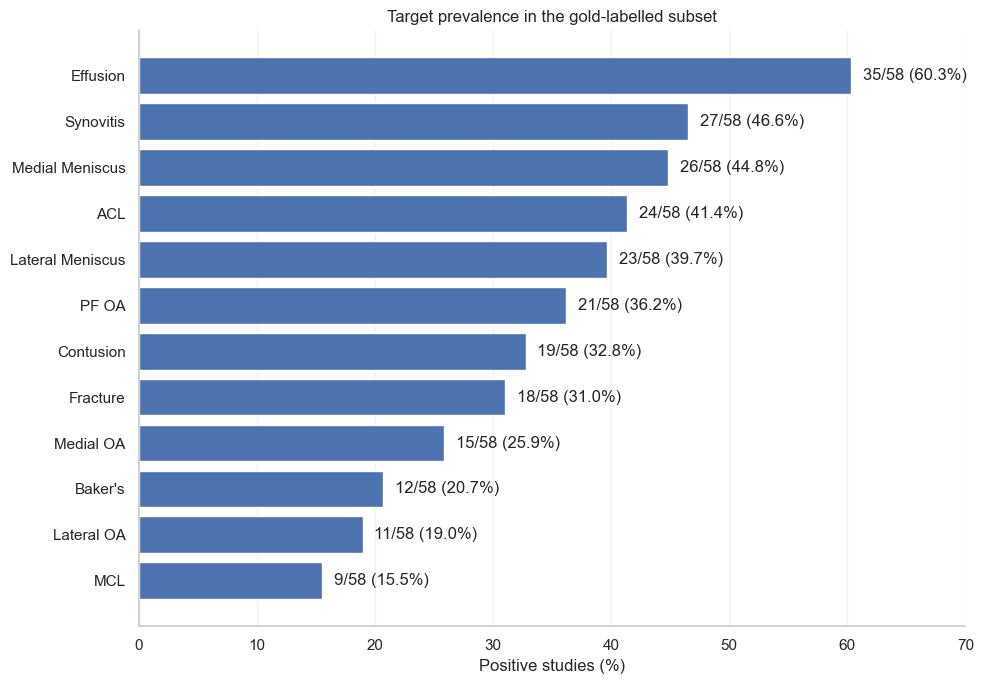

In [10]:
# ===================================
# 4.1 Visualise individual target prevalence (個々のターゲットの有病率の可視化)
# ===================================

prevalence_plot = target_summary.sort_values("positive_percentage").reset_index(
    drop=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    prevalence_plot["target"],
    prevalence_plot["positive_percentage"],
    color=sns.color_palette("deep")[0],
)

for bar, positive_cases, percentage in zip(
    bars,
    prevalence_plot["positive_cases"],
    prevalence_plot["positive_percentage"],
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{positive_cases}/58 ({percentage:.1f}%)",
        va="center",
    )

ax.set_xlim(0, 70)
ax.set_xlabel("Positive studies (%)")
ax.set_ylabel("")
ax.set_title("Target prevalence in the gold-labelled subset")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

## 4.2 Count positive labels per study(研究ごとの陽性ラベルの数のカウント)


In [11]:
# ===================================
# 4.2 Count positive labels per study (研究ごとの陽性ラベルの数のカウント)
# ===================================

gold_labels = labelled_train[TARGET_COLUMNS].astype(int).copy()

positive_labels_per_study = gold_labels.sum(axis=1)

positive_labels_summary = pd.DataFrame(
    {
        "metric": [
            "Gold-labelled studies",
            "Total positive labels",
            "Mean positive labels per study",
            "Median positive labels per study",
            "Minimum positive labels per study",
            "Maximum positive labels per study",
            "Studies with no positive labels",
            "Studies with at least one positive label",
        ],
        "value": [
            len(gold_labels),
            positive_labels_per_study.sum(),
            positive_labels_per_study.mean(),
            positive_labels_per_study.median(),
            positive_labels_per_study.min(),
            positive_labels_per_study.max(),
            (positive_labels_per_study == 0).sum(),
            (positive_labels_per_study > 0).sum(),
        ],
    }
)

display(positive_labels_summary)

,metric,value
0,Gold-labelled studies,58.0000
1,Total positive labels,240.0000
2,Mean positive labels per study,4.1379
3,Median positive labels per study,4.0000
4,Minimum positive labels per study,1.0000
5,Maximum positive labels per study,9.0000
6,Studies with no positive labels,0.0000
7,Studies with at least one positive label,58.0000


## 4.3 Visualize positive labels per study(研究ごとの陽性ラベルの可視化)


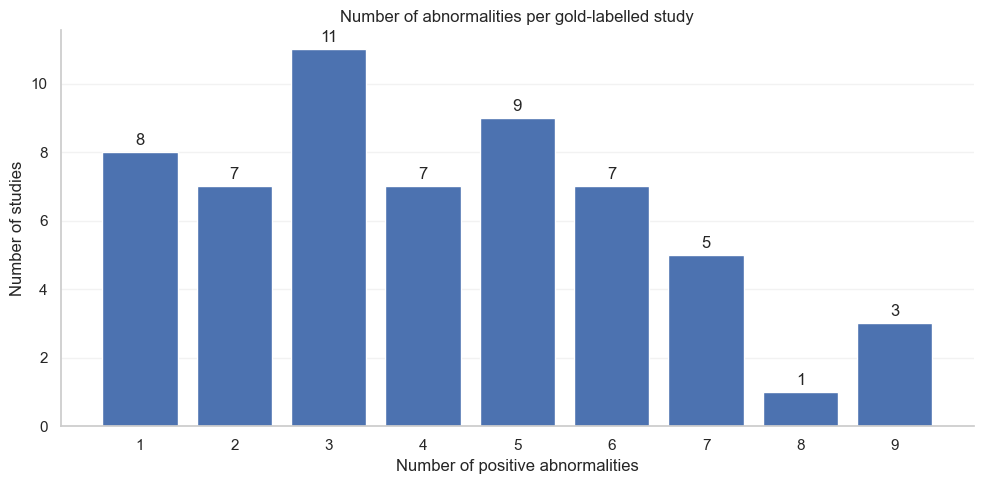

In [12]:
# ===================================
# 4.3 Visualise positive labels per study (研究ごとの陽性ラベルの可視化)
# ===================================

label_count_distribution = (
    positive_labels_per_study.value_counts()
    .sort_index()
    .reindex(
        range(
            int(positive_labels_per_study.min()),
            int(positive_labels_per_study.max()) + 1,
        ),
        fill_value=0,
    )
    .rename_axis("positive_labels")
    .reset_index(name="number_of_studies")
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    label_count_distribution["positive_labels"],
    label_count_distribution["number_of_studies"],
    color=sns.color_palette("deep")[0],
)

ax.bar_label(bars, padding=3)

ax.set_xlabel("Number of positive abnormalities")
ax.set_ylabel("Number of studies")
ax.set_title("Number of abnormalities per gold-labelled study")
ax.set_xticks(label_count_distribution["positive_labels"])
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

## Key Findings(主な発見)

The gold labelled studies have an average of **4.14 positive abnormalities per study**. with the median of 4 and range of 1 to 8 positive abnormalities per study.

Every one of 58 studies has at least 1 positive abnormality, and there is no study with all negative abnormalities. This indicates that the labelled studies are not representative of the general population, and may be rare cases.

The high number of findings per study also confirms that this is a genuinely multi-label proble. Models must be able to identify several co-existing abnormalities rather than select a single diagonosis.

ゴールドラベル付き研究では、1件の研究あたり平均**4.14件の陽性異常**があり、中央値は4、範囲は1〜8件の陽性異常です。

各58件の研究には少なくとも1件の陽性異常があり、すべての異常が陰性である研究はありません。これは、ラベル付き研究が一般集団を代表しておらず、稀なケースである可能性があることを示しています。

高い件数の異常が1件の研究に含まれていることは、これは本当にマルチラベル問題であることを確認するものです。モデルは、単一の診断を選択するのではなく、共存する複数の異常を識別できる必要があります。


## 4.4 Find more about co-occurrence of abnormalities(異常の共起についてさらに調べる)

Some knee abnormalities may frequently appear together and some may never appear together. We will explore the co-occurrence of abnormalities in this section.
The following heatmap shows the co-occurrence of abnormalities in the 58 gold-labelled studies. The values in the heatmap represent the number of studies that have both abnormalities present.

いくつかの膝の異常は一緒に現れることが多く、いくつかは一緒に現れることがない場合があります。このセクションでは、異常の共起について調べます。
以下のヒートマップは、58件のゴールドラベル付き研究における異常の共起を示しています。ヒートマップの値は、両方の異常が存在する研究の数を表しています。


### 4.4.1 Heatmap of co-occurrence of abnormalities(異常の共起のヒートマップ)


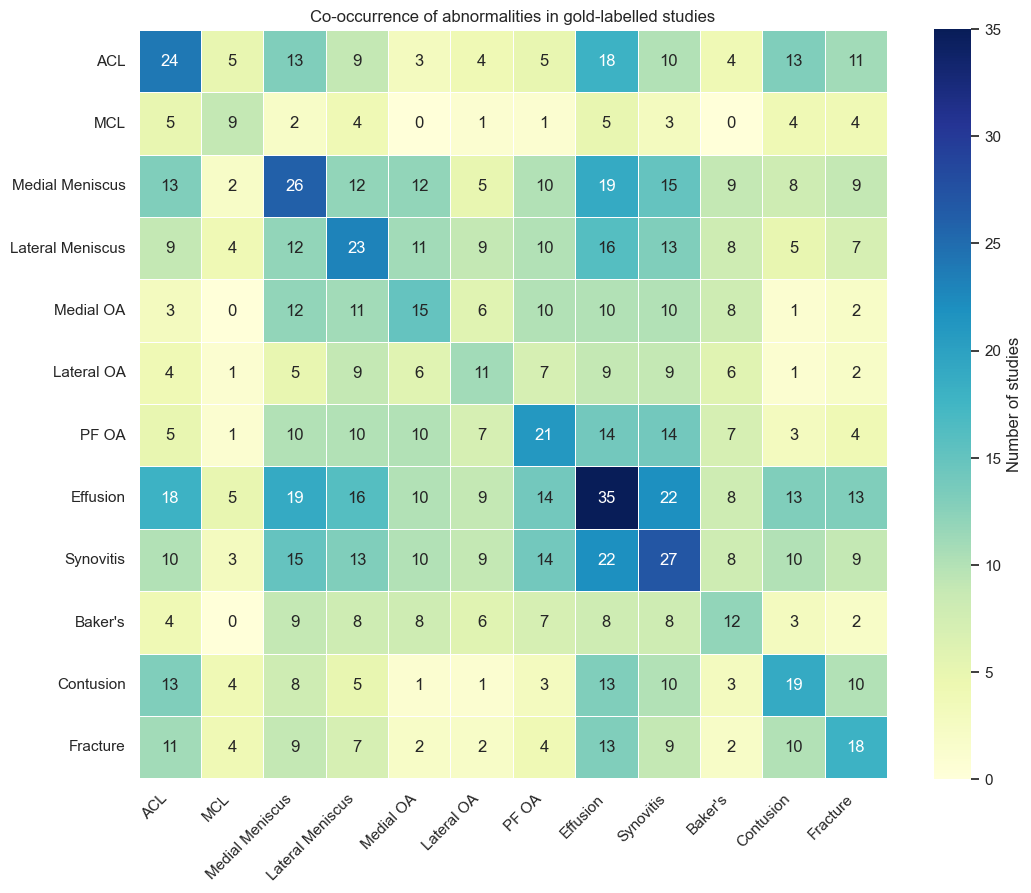

In [13]:
# ==================================
# 4.4.1 Heatmap of co-occurrence of abnormalities (異常の共起のヒートマップ)
# ==================================

co_occurrence_matrix = gold_labels.T.dot(gold_labels)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    co_occurrence_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={"label": "Number of studies"},
    square=True,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Co-occurrence of abnormalities in gold-labelled studies")
ax.set_xlabel("")
ax.set_ylabel("")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.4.2. Sumarize the most co-occurring target pairs(最も共起するターゲットペアの要約)


In [14]:
# ==================================
# 4.4.2 Sumarize the most frequent target pairs (最も頻繁に出現するターゲットペアの要約)
# ==================================

pair_rows = []

for first_index, first_target in enumerate(TARGET_COLUMNS):
    for second_target in TARGET_COLUMNS[first_index + 1 :]:
        first_positive = gold_labels[first_target] == 1
        second_positive = gold_labels[second_target] == 1

        both_positive = int((first_positive & second_positive).sum())

        either_positive = int((first_positive | second_positive).sum())

        pair_rows.append(
            {
                "first_target": first_target,
                "second_target": second_target,
                "both_positive": both_positive,
                "percentage_of_gold_studies": (both_positive / len(gold_labels) * 100),
                "jaccard_similarity": (
                    both_positive / either_positive if either_positive > 0 else np.nan
                ),
            }
        )

target_pairs = (
    pd.DataFrame(pair_rows)
    .sort_values(
        ["both_positive", "jaccard_similarity"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(target_pairs.head(15))

,first_target,second_target,both_positive,percentage_of_gold_studies,jaccard_similarity
0,Effusion,Synovitis,22,37.9310,0.5500
1,Medial Meniscus,Effusion,19,32.7586,0.4524
2,ACL,Effusion,18,31.0345,0.4390
3,Lateral Meniscus,Effusion,16,27.5862,0.3810
4,Medial Meniscus,Synovitis,15,25.8621,0.3947
5,PF OA,Synovitis,14,24.1379,0.4118
6,PF OA,Effusion,14,24.1379,0.3333
7,ACL,Contusion,13,22.4138,0.4333
8,ACL,Medial Meniscus,13,22.4138,0.3514
9,Lateral Meniscus,Synovitis,13,22.4138,0.3514


### 4.4.3 Visualize the most co-occurring target pairs(最も共起するターゲットペアの可視化)


In [15]:
# ==================================
# 4.4.3 Visualize the least co-occurring target pairs (最も共起しないターゲットペアの可視化)
# ==================================

display(target_pairs.tail(15)[::-1])

,first_target,second_target,both_positive,percentage_of_gold_studies,jaccard_similarity
65,MCL,Baker's,0,0.0000,0.0000
64,MCL,Medial OA,0,0.0000,0.0000
63,Medial OA,Contusion,1,1.7241,0.0303
62,Lateral OA,Contusion,1,1.7241,0.0345
61,MCL,PF OA,1,1.7241,0.0345
60,MCL,Lateral OA,1,1.7241,0.0526
59,MCL,Medial Meniscus,2,3.4483,0.0606
58,Medial OA,Fracture,2,3.4483,0.0645
57,Baker's,Fracture,2,3.4483,0.0714
56,Lateral OA,Fracture,2,3.4483,0.0741


### Key Findings(主な発見)

The strongest observed overlap is between **Effusion and Synovitis**. Both are present in 22 studies, representing 37.9% of the gold subset. Their Jaccard similarity of 0.55 means that 55% of studies containing either finding contain both.

Other frequent combinations include:

- Medial Meniscus injury with Effusion: 19 studies;
- ACL injury with Effusion: 18 studies;
- Lateral Meniscus injury with Effusion: 16 studies;
- Medial Meniscus injury with Synovitis: 15 studies; and
- PF OA with Synovitis: 14 studies.

Some less frequent targets also show notable proportional overlap. For example, ACL injury and Contusion have a Jaccard similarity of 0.43, while Medial Meniscus injury and Medial OA have a similarity of 0.41.

Raw co-occurrence counts are partly influenced by individual target prevalence. Effusion appears in many of the leading pairs because it is the most common target. The Jaccard similarity provides additional context by measuring overlap relative to how often either target occurs.

These relationships are exploratory. With only 58 studies, they should not be interpreted as precise or causal clinical associations.

The least co-occurring target pairs are:

- MCL injury and Baker's cyst: 0 studies;
- MCL injury and Contusion: 0 studies;

These pairs are never observed together in the gold subset. But with only 58 studies, this does not mean that they cannot co-occur in the general population. It is possible that these pairs are simply rare.

**EffusionとSynovitis**の間に最も強い重なりが観察されました。両方とも22件の研究に存在し、ゴールドサブセットの37.9％を占めています。ジャカード類似度が0.55であることは、いずれかの所見を含む研究の55％が両方を含むことを意味します。

出現頻度が低いターゲットでも、注目すべき割合の重なりを示すものがあります。たとえば、ACL損傷と打撲（Contusion）のジャカード類似度は0.43であり、内側半月板損傷（Medial Meniscus injury）と内側OA（Medial OA）の類似度は0.41です。

同時発生の生のカウントは、個々のターゲットの有病率に部分的に影響されます。Effusionは最も一般的なターゲットであるため、主要なペアの多くに現れます。ジャカード類似度は、いずれかのターゲットがどのくらい頻繁に発生するかに対して重なりを測定することで、追加のコンテキストを提供します。

これらの関係は探索的なものであり、58件の研究しかないため、正確または因果的な臨床関連として解釈すべきではありません。


# 5. Radiology report analysis(放射線レポートの分析)

only 58 studies contains labels that are properly structured. Remaining 4349 studies, the accompanying radiology reports are the only source of information about the presence or absence of abnormalities.

Before attempting to extract weak labels, we need to understand:

- report completeness and uniqueness;
- report length and structure;
- difference between gold-labelled and report-only studies;
- repeated or templated reports;
- language distribution and multilingual reports;
- how consistently the 12 abnormalities are mentioned in the reports;

たった58件の研究のみが適切に構造化されたラベルを含んでいます。残りの4,349件の研究では、付随する放射線レポートが、異常の有無に関する唯一の情報源です。

弱いラベルを抽出しようとする前に、次の点を理解する必要があります。

- レポートの完全性と一意性
- レポートの長さと構造
- ゴールドラベル付き研究とレポートのみの研究の違い
- 繰り返しまたはテンプレート化されたレポート
- 言語の分布と多言語レポート
- レポートで12の異常がどの程度一貫して言及されているか


## 5.1. Report completeness and uniqueness(レポートの完全性と一意性)


In [30]:
# ==================================
# 5.1.1 Prepare the radiology reports for analysis(放射線レポートの分析の準備)
# ==================================

report_data = train[[ID_COLUMN, "Report"]].copy()

report_data["label_status"] = np.where(
    fully_labelled_studies,
    "Gold-labelled",
    "Report-only",
)

report_data["normalized_report"] = (
    report_data["Report"]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

report_data["report_characters"] = report_data["Report"].fillna("").str.len()

report_data["report_words"] = report_data["Report"].fillna("").str.split().map(len)

report_data["report_lines"] = report_data["Report"].fillna("").str.count("\n").add(1)

report_data["exact_duplicate"] = report_data["Report"].duplicated(keep=False)

report_data["normalized_duplicate"] = report_data["normalized_report"].duplicated(
    keep=False
)

In [17]:
# ==================================
# 5.1.2 Report Coverage and uniqueness(レポートのカバレッジと一意性)
# ==================================

report_coverage_summary = pd.DataFrame(
    {
        "metric": [
            "Training studies",
            "Missing reports",
            "Empty reports",
            "Unique reports (exact match)",
            "Unique reports (normalized match)",
            "Rows belonging to exact duplicate reports",
            "Rows belonging to normalized duplicate reports",
        ],
        "value": [
            len(report_data),
            report_data["Report"].isna().sum(),
            (report_data["Report"].fillna("") == "").sum(),
            report_data["Report"].nunique(dropna=True),
            report_data["normalized_report"].nunique(dropna=True),
            report_data["exact_duplicate"].sum(),
            report_data["normalized_duplicate"].sum(),
        ],
    }
)

display(report_coverage_summary)

,metric,value
0,Training studies,4407
1,Missing reports,0
2,Empty reports,0
3,Unique reports (exact match),4276
4,Unique reports (normalized match),4257
5,Rows belonging to exact duplicate reports,177
6,Rows belonging to normalized duplicate reports,204


## Key Findings(主な発見)

All 4,407 studies have accompanying radiology reports.

Most of the reports are unique, but some are repeated across multiple studies. The repeated reports may be due to templated reporting or similar findings across different patients. 204 reports are repeated across multiple studies, but this is only affects a small fraction of the dataset.

全ての4,407件の研究には、付随する放射線レポートがあります。

ほとんどのレポートは一意ですが、一部は複数の研究で繰り返されています。繰り返されるレポートは、テンプレート化された報告や、異なる患者間での類似した所見による可能性があります。204件のレポートが複数の研究で繰り返されていますが、これはデータセットのごく一部にしか影響しません。


## 5.2. Report length and structure(レポートの長さと構造)

Report length will provide insight into how much textual information is available for extracting weak labels.

We will compare report-only studies to check wether the gold subsets contains systematically diffrent reports.

レポートの長さは、弱いラベルを抽出するために利用可能なテキスト情報の量についての洞察を提供します。

ラベルのみの研究と比較して、ゴールドサブセットが体系的に異なるレポートを含んでいるかどうかを確認します。


In [23]:
# ==================================
# 5.2. Report length and structure(レポートの長さと構造)
# ==================================


def report_length_summary(
    df: pd.DataFrame, group_col: str = "label_status"
) -> pd.DataFrame:
    """Summarize report length metrics by group."""
    summary = (
        df.groupby(group_col)
        .agg(
            mean_characters=("report_characters", "mean"),
            q1_characters=("report_characters", lambda values: values.quantile(0.25)),
            median_characters=("report_characters", "median"),
            q3_characters=("report_characters", lambda values: values.quantile(0.75)),
            min_characters=("report_characters", "min"),
            max_characters=("report_characters", "max"),
            mean_words=("report_words", "mean"),
            q1_words=("report_words", lambda values: values.quantile(0.25)),
            median_words=("report_words", "median"),
            q3_words=("report_words", lambda values: values.quantile(0.75)),
            min_words=("report_words", "min"),
            max_words=("report_words", "max"),
            mean_lines=("report_lines", "mean"),
            median_lines=("report_lines", "median"),
            min_lines=("report_lines", "min"),
            max_lines=("report_lines", "max"),
        )
        .reset_index()
        .set_index(group_col)
        .T
    )
    return summary


report_length_summary_df = report_length_summary(report_data)

display(report_length_summary_df)

label_status,Gold-labelled,Report-only
mean_characters,1305.0862,1095.1426
q1_characters,818.2500,586.0000
median_characters,1205.5000,974.0000
q3_characters,1777.2500,1455.0000
min_characters,183.0000,52.0000
max_characters,3891.0000,4743.0000
mean_words,179.0000,147.1235
q1_words,98.5000,74.0000
median_words,161.5000,128.0000
q3_words,232.5000,201.0000


## 5.3. Visualize report length distribution(レポートの長さの分布の可視化)


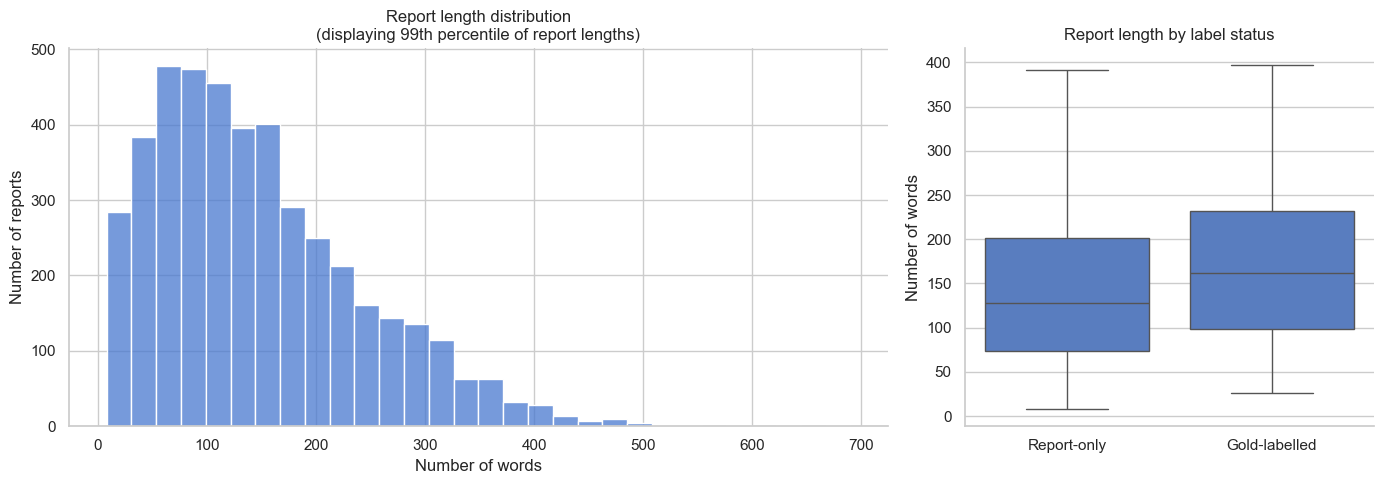

In [29]:
# ==================================
# 5.3 Visualize report length distribution(レポートの長さの分布の可視化)
# ==================================

world_limits = report_data["report_characters"].quantile([0.01, 0.99]).values

plot_reports = report_data.loc[report_data["report_words"] <= world_limits[1]].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)

sns.histplot(
    data=plot_reports,
    x="report_words",
    bins=30,
    ax=axes[0],
)

axes[0].set_title(
    "Report length distribution\n" "(displaying 99th percentile of report lengths)"
)
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Number of reports")

sns.boxplot(
    data=report_data,
    x="label_status",
    y="report_words",
    showfliers=False,
    ax=axes[1],
)

axes[1].set_title("Report length by label status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of words")

sns.despine()
plt.tight_layout()
plt.show()